##### 기사 크롤링하기

In [3]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

def make_urllist(page_num, code, date):
    urllist = []
    for i in range(1, page_num + 1):
        url = 'https://news.naver.com/main/list.nhn?mode=LSD&mid=sec&sid1='+str(code)+'&date='+str(date)+'&page='+str(i) 
        headers = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/54.0.2840.90 Safari/537.36'}
        news = requests.get(url, headers=headers)
        soup = BeautifulSoup(news.content, 'html.parser')
        
        news_list = soup.select('.newsflash_body .type06_headline li dl')
        news_list.extend(soup.select('.newsflash_body .type06_headline li dl'))       

        for line in news_list:
            urllist.append(line.a.get('href'))
    return urllist
    

In [4]:
from newspaper import Article

#데이터 프레임 생성
def make_data(urllist, code):
    text_list = []
    for url in urllist:
        article = Article(url, language='ko')
        article.download()
        article.parse()
        text_list.append(article.text)
    
    df = pd.DataFrame({'news':text_list})
    
    df['code'] = idx2word[str(code)]
    return df

In [5]:
#다양한 섹션에서의 크롤링하기
#섹션설정
code_list = [102, 103, 105]
code_list

[102, 103, 105]

In [6]:
#크롤링을 섹션들로 나누어 프레임에 저장하기 
def make_total_data(page_num, code_list, date):
    df = None
    
    for code in code_list:
        url_list = make_urllist(page_num, code, date)
        df_temp = make_data(url_list, code)
        print(str(code))
        
        if df is not None:
            df = pd.concat([df, df_temp])
        else:
            df = df_temp
            
    return df

In [14]:
#데이터 프레임들 합치기. 다른 데이터들과 합쳐보기. 
import os
csv_path = os.getenv("HOME") + "/aiffel/news_crawler/news_data.csv"
df = pd.read_csv(csv_path)
df


,news,code
0,제주국제학교에 다니는 학생이 신종 코로나바이러스 감염증(코로나19)에 확진돼 해당 ...,사회
1,http://news.kbs.co.kr/news/list.do?icd=19588\n...,사회
2,기사 섹션 분류 안내\n\n기사의 섹션 정보는 해당 언론사의 분류를 따르고 있습니다...,사회
3,대구공업고등학교 동문 기업CEO들이 19일 대구 인터불고호텔에서 지역 취업 활성화를...,사회
4,"한국노총은 19일 발표한 성명서를 통해 ""공공으로 교육과 돌봄서비스를 제공하는 단체...",사회
...,...,...
4723,[서울=뉴시스] 김종민 기자 = 스마트폰 교체 결정에 가장 영향력을 미치는 미디어는...,IT/과학
4724,[스포츠서울 김수지기자] 애플의 아이폰12 PRO가 지난 30일 정식 출시를 진행한...,IT/과학
4725,[사진=블리자드] [사진=블리자드]\n\n[사진=블리자드] [사진=블리자드]\n\n...,IT/과학
4726,[서울=뉴시스] 김종민 기자 = 스마트폰 교체 결정에 가장 영향력을 미치는 미디어는...,IT/과학


In [12]:

csv_path2 = os.getenv("HOME") + "/aiffel/news_crawler/news_data2.csv"
df2 = pd.read_csv(csv_path2)
df2.head()

,news,code
0,오늘(6일) 오후 1시 40분쯤 전북 군산시 나포면의 한 고물상에서 불이 났습니다....,사회
1,[한국경제TV 김주리 기자]\n\n경남 거창군 일원에서 50대 약초꾼이 100년이 ...,사회
2,비상착륙 중 화재로 41명이 숨진 러시아 아에로플로트항공 소속 '수호이 슈퍼제트 1...,사회
3,6일 오후 4시3분쯤 충남 청양군 청양읍 A(65)씨 양계장에서 불이 나 키우던 닭...,사회
4,아프리카 탄자니아의 기린과 얼룩말\n\n[AP=연합뉴스 자료사진] 아프리카 탄자니아...,사회


In [13]:
df3 = pd.concat([df, df2])
df3

,news,code
0,제주국제학교에 다니는 학생이 신종 코로나바이러스 감염증(코로나19)에 확진돼 해당 ...,사회
1,http://news.kbs.co.kr/news/list.do?icd=19588\n...,사회
2,기사 섹션 분류 안내\n\n기사의 섹션 정보는 해당 언론사의 분류를 따르고 있습니다...,사회
3,대구공업고등학교 동문 기업CEO들이 19일 대구 인터불고호텔에서 지역 취업 활성화를...,사회
4,"한국노총은 19일 발표한 성명서를 통해 ""공공으로 교육과 돌봄서비스를 제공하는 단체...",사회
...,...,...
1123,글로벌 정보기술(IT) 공룡들이 ‘구독(購讀) 경제’ 플랫폼에 눈독을 들이고 있다....,IT/과학
1124,인터넷을 통해 환자들에게 성형시술 쿠폰을 판매한 뒤 병원으로부터 수수료로 받는 행위...,IT/과학
1125,[이재현 기자]마블 스튜디오의 영화 ‘어벤저스：엔드게임’의 흥행에 힘입어 넷마블의 ...,IT/과학
1126,[이재현 기자]넥슨이 온라인 RPG ‘바람의나라’에 ‘바린이 나르샤’ 프로모션을 진...,IT/과학


In [15]:
csv_path4 = os.getenv("HOME") + "/aiffel/news_crawler/news_data2.csv"
df4 = pd.read_csv(csv_path2)

In [16]:
csv_path5 = os.getenv("HOME") + "/aiffel/news_crawler/news_data2.csv"
df5 = pd.read_csv(csv_path2)

In [17]:
csv_path6 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200129"
df6 = pd.read_csv(csv_path2)

In [18]:
csv_path7 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200215"
df7 = pd.read_csv(csv_path2)

In [19]:
csv_path8 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200315"
df8 = pd.read_csv(csv_path2)

In [20]:
csv_path9 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200429"
df9 = pd.read_csv(csv_path2)

In [21]:
csv_path10 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200530"
df10 = pd.read_csv(csv_path2)

In [22]:
csv_path11 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200614"
df11 = pd.read_csv(csv_path2)

In [23]:
csv_path12 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200715"
df12 = pd.read_csv(csv_path2)

In [24]:
csv_path13 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200819"
df13 = pd.read_csv(csv_path2)

In [25]:
csv_path14 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20200914"
df14 = pd.read_csv(csv_path2)

In [26]:
csv_path15 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20201024"
df15 = pd.read_csv(csv_path2)

In [27]:
csv_path16 = os.getenv("HOME") + "news_20_[101, 102, 103, 105]_20201119"
df16 = pd.read_csv(csv_path2)

In [28]:
df = pd.concat([df3, df4, df5,
               df6,
               df7,
               df8,
               df9,
               df10,
               df11,
               df12,
               df13,
               df14, df15, df16])


In [29]:
df

,news,code
0,제주국제학교에 다니는 학생이 신종 코로나바이러스 감염증(코로나19)에 확진돼 해당 ...,사회
1,http://news.kbs.co.kr/news/list.do?icd=19588\n...,사회
2,기사 섹션 분류 안내\n\n기사의 섹션 정보는 해당 언론사의 분류를 따르고 있습니다...,사회
3,대구공업고등학교 동문 기업CEO들이 19일 대구 인터불고호텔에서 지역 취업 활성화를...,사회
4,"한국노총은 19일 발표한 성명서를 통해 ""공공으로 교육과 돌봄서비스를 제공하는 단체...",사회
...,...,...
1123,글로벌 정보기술(IT) 공룡들이 ‘구독(購讀) 경제’ 플랫폼에 눈독을 들이고 있다....,IT/과학
1124,인터넷을 통해 환자들에게 성형시술 쿠폰을 판매한 뒤 병원으로부터 수수료로 받는 행위...,IT/과학
1125,[이재현 기자]마블 스튜디오의 영화 ‘어벤저스：엔드게임’의 흥행에 힘입어 넷마블의 ...,IT/과학
1126,[이재현 기자]넥슨이 온라인 RPG ‘바람의나라’에 ‘바린이 나르샤’ 프로모션을 진...,IT/과학


In [93]:
from glob import glob
pdA = pd.concat(map(pd.read_csv, glob('./news_crawler/*.csv')), ignore_index=True)

ValueError: No objects to concatenate

In [37]:
df.columns

Index(['news', 'code'], dtype='object')

In [39]:
df['news'] = df['news'].str.replace("[^ㄱ-ㅎ ㅏ-ㅣ 가-힣]","")
df['news']

0       제주국제학교에 다니는 학생이 신종 코로나바이러스 감염증코로나에 확진돼 해당 학교가 ...
1       정세균국무총리  최근 코로나 확산세가 거세지면서 다시 한 번 방역이 위기를 맞고 있...
2       기사 섹션 분류 안내기사의 섹션 정보는 해당 언론사의 분류를 따르고 있습니다 언론사...
3       대구공업고등학교 동문 기업들이 일 대구 인터불고호텔에서 지역 취업 활성화를 모색하는...
4       한국노총은 일 발표한 성명서를 통해 공공으로 교육과 돌봄서비스를 제공하는 단체인 사...
                              ...                        
1123    글로벌 정보기술 공룡들이 구독 경제 플랫폼에 눈독을 들이고 있다 아이폰 판매 부진에...
1124    인터넷을 통해 환자들에게 성형시술 쿠폰을 판매한 뒤 병원으로부터 수수료로 받는 행위...
1125    이재현 기자마블 스튜디오의 영화 어벤저스엔드게임의 흥행에 힘입어 넷마블의 모바일 액...
1126    이재현 기자넥슨이 온라인  바람의나라에 바린이 나르샤 프로모션을 진행한다일 업데이트...
1127    코오롱생명과학이 문제가 된 무릎 골관절염 유전자 치료제인 인보사케이주인보사의 성분이...
Name: news, Length: 20520, dtype: object

In [40]:
print(df.isnull().sum())

news    0
code    0
dtype: int64


In [43]:
df.drop_duplicates(subset=['news'], inplace=True)

print('뉴스 기사의 개수:', len(df))

뉴스 기사의 개수: 4244


<AxesSubplot:>

/home/goldhanwool/anaconda3/envs/aiffel/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 49324 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/goldhanwool/anaconda3/envs/aiffel/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 54924 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/goldhanwool/anaconda3/envs/aiffel/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 49373 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/goldhanwool/anaconda3/envs/aiffel/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 54876 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/goldhanwool/anaconda3/envs/aiffel/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 47928 missing from current font.
  font.set_text(s, 0.0, flags=flags)


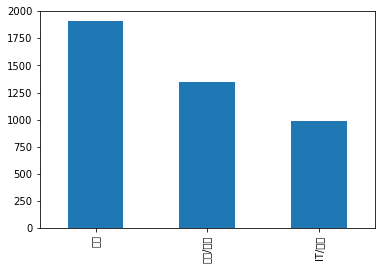

In [44]:
df['code'].value_counts().plot(kind = 'bar')

In [45]:
print(df.groupby('code').size().reset_index(name='count'))

    code  count
0  IT/과학    987
1     사회   1906
2  생활/문화   1351


In [81]:
#불용어 제거
stopwords = ['습니다', '밝','혔','에','는','은','을','를', '했','에게','있','이','의','하','한','다','과','때문','할','수','무단','따른','및','금지','전재','경향신문','에서','겠', '해', '만', '라는','기자','는데','가','등','까지','들','파이낸셜','저작','등','뉴스']

In [82]:
# 토큰화 및 토큰화 과정에서 불용어를 제거하는 함수입니다.
from konlpy.tag import Mecab
tokenizer = Mecab()

def preprocessing(data):
  text_data = []

  for sentence in data:
    temp_data = []
    #- 토큰화
    temp_data = tokenizer.morphs(sentence) 
    #- 불용어 제거
    temp_data = [word for word in temp_data if not word in stopwords] 
    text_data.append(temp_data)

  text_data = list(map(' '.join, text_data))

  return text_data

print('ok')

ok


In [83]:
text_data = preprocessing(df['news'])
print(text_data[1])

정세균 국무총리 최근 코로나 확산 세 거세 지 면서 다시 번 방역 위기 맞 고 일상 생활 곳곳 동시 다발 적 으로 발생 고 어 상황 더욱 심각 합니다 그 동안 확진 자 거의 없 었 던 산간 마을 도 집단 감염 발생 면서 이제 전국 어디 도 안전 곳 없 다는 불안감 커지 고 젊은이 협조 무엇 보다 필요 합니다 무증상 감염 많 젊 층 특성 상 확산 범위 와 속도 감당 기 어렵 연말 맞 아 계획 고 각종 모임 최대한 자제 주 시 고 필수 적 인 활동 이외 가급적 집안 머물러 주 십시오 특히 세 이상 연령 층 겨울철 건강 관리 유의 면서 불 필요 외출 만남 최소 화 주 시 기 바랍니다 백신 실제 국민 접종 되 기 상당 시간 필요 합니다 그때 마스크 쓰 기 철저 방역 수칙 준수 유일 예방책 점 시 라도 잊 어서 안 되


# Learning

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [89]:
#- 훈련 데이터와 테스트 데이터를 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(text_data, df['code'], random_state = 0)

In [90]:
#- 단어의 수를 카운트하는 사이킷런의 카운트벡터라이저입니다.
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)

#- 카운트벡터라이저의 결과로부터 TF-IDF 결과를 얻습니다.
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

#- 나이브 베이즈 분류기를 수행합니다.
#- X_train은 TF-IDF 벡터, y_train은 레이블입니다.
clf = MultinomialNB().fit(X_train_tfidf, y_train)

In [91]:
def tfidf_vectorizer(data):
    data_counts = count_vect.transform(data)
    data_tfidf = tfidf_transformer.transform(data_counts)
    return data_tfidf

In [92]:
y_pred = clf.predict(tfidf_vectorizer(X_test))
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       IT/과학       0.94      0.73      0.82       255
          사회       0.77      0.95      0.85       490
       생활/문화       0.85      0.71      0.77       316

    accuracy                           0.82      1061
   macro avg       0.85      0.79      0.82      1061
weighted avg       0.84      0.82      0.82      1061

